In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
!wget https://raw.githubusercontent.com/DivyamAwasthy/chicago-crime-risk-predictor/main/crime_risk_aggregated.csv

--2026-05-26 14:38:31--  https://raw.githubusercontent.com/DivyamAwasthy/chicago-crime-risk-predictor/main/crime_risk_aggregated.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3406294 (3.2M) [text/plain]
Saving to: ‘crime_risk_aggregated.csv’

crime_risk_aggregat 100%[===================>]   3.25M  14.3MB/s    in 0.2s    

2026-05-26 14:38:32 (14.3 MB/s) - ‘crime_risk_aggregated.csv’ saved [3406294/3406294]



In [4]:
# Load the aggregated data we saved from 01_eda.ipynb
agg = pd.read_csv('crime_risk_aggregated.csv')
print(f"Loaded: {agg.shape}")

# FEATURES: Only things we know at prediction time
# When a user queries "lat=41.85, lon=-87.65, Saturday, 11 PM" —
# these are the only things available:
features = ['lat_bin', 'lon_bin', 'hour', 'day_of_week', 'is_weekend']

# TARGET: risk_level (Low / Medium / High)
target = 'risk_level'

X = agg[features].copy()
y = agg[target].copy()

# LabelEncoder converts string labels to numbers
# WHY? XGBoost and most sklearn models need numeric targets
# This just maps: High→0, Low→1, Medium→2 (alphabetical order)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nClass mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

# Train-test split
# stratify=y_encoded ensures both train and test have the same
# proportion of Low/Medium/High — without this, you might accidentally
# get very few "High" samples in test set and metrics would be unreliable
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")

# Verify stratification
print(f"\nClass distribution in train:")
for i, label in enumerate(le.classes_):
    pct = (y_train == i).mean() * 100
    print(f"  {label}: {(y_train == i).sum()} ({pct:.1f}%)")

print(f"\nClass distribution in test:")
for i, label in enumerate(le.classes_):
    pct = (y_test == i).mean() * 100
    print(f"  {label}: {(y_test == i).sum()} ({pct:.1f}%)")

Loaded: (78494, 10)

Class mapping:
  High → 0
  Low → 1
  Medium → 2

Train: (62795, 5)
Test:  (15699, 5)

Class distribution in train:
  High: 17817 (28.4%)
  Low: 29585 (47.1%)
  Medium: 15393 (24.5%)

Class distribution in test:
  High: 4454 (28.4%)
  Low: 7396 (47.1%)
  Medium: 3849 (24.5%)


In [5]:
# WHY Logistic Regression as baseline?
#
# Interview answer: "I always start with a simple interpretable model
# to establish a performance floor. If a complex model like XGBoost
# can't meaningfully beat LogReg, it means either:
#   (a) the features aren't informative enough, or
#   (b) the problem is inherently linear and you don't need complexity"
#
# StandardScaler is needed for LogReg because it uses gradient descent
# internally — features on different scales (lat ~41 vs hour ~0-23)
# would make convergence slow and biased toward larger-valued features
#
# XGBoost does NOT need scaling (it's tree-based, splits don't care
# about scale) but we scale anyway inside ColumnTransformer for
# consistency and good practice

baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,        # enough iterations to converge
        random_state=42,
        multi_class='multinomial'  # 3 classes, not binary
    ))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

print("=== BASELINE: Logistic Regression ===\n")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

=== BASELINE: Logistic Regression ===

              precision    recall  f1-score   support

        High       0.43      0.35      0.39      4454
         Low       0.51      0.84      0.64      7396
      Medium       0.00      0.00      0.00      3849

    accuracy                           0.49     15699
   macro avg       0.32      0.40      0.34     15699
weighted avg       0.36      0.49      0.41     15699



In [7]:
# ColumnTransformer: wraps preprocessing for different feature types
# Right now all our features are numeric so we only have one transformer
# BUT this structure is production-ready — if you later add a categorical
# feature (like crime_type or location_description), you just add another
# entry here instead of rewriting everything
#
# WHY still use ColumnTransformer if XGBoost doesn't need scaling?
# 1. Shows interviewers you know production ML patterns
# 2. Makes the pipeline pickle-able as one object for deployment
# 3. Easy to extend later

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features)
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,     # number of trees — 200 is a safe starting point
        max_depth=6,          # how deep each tree can go — controls overfitting
        learning_rate=0.1,    # how much each new tree corrects the previous ones
        random_state=42,
        eval_metric='mlogloss'  # multiclass log loss — standard for 3+ classes
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print("=== XGBoost (No SMOTE) ===\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

=== XGBoost (No SMOTE) ===

              precision    recall  f1-score   support

        High       0.65      0.75      0.70      4454
         Low       0.68      0.85      0.76      7396
      Medium       0.38      0.12      0.18      3849

    accuracy                           0.65     15699
   macro avg       0.57      0.58      0.55     15699
weighted avg       0.60      0.65      0.60     15699



In [8]:
# imbalanced-learn has its own Pipeline that supports SMOTE mid-pipeline
# Regular sklearn Pipeline does NOT allow samplers (SMOTE) inside it
# That's why we import from imblearn instead
#
# HOW SMOTE WORKS (from your video 133):
# It picks a minority class sample, finds its k nearest neighbors
# in feature space, and creates synthetic points along the line
# between them. This gives the model more "Medium" examples to learn from.
#
# IMPORTANT: SMOTE is applied ONLY to training data, never test data
# The imblearn Pipeline handles this automatically — during .fit()
# it applies SMOTE, during .predict() it skips SMOTE

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)

print("=== XGBoost + SMOTE ===\n")
print(classification_report(y_test, y_pred_smote, target_names=le.classes_))

=== XGBoost + SMOTE ===

              precision    recall  f1-score   support

        High       0.64      0.75      0.69      4454
         Low       0.73      0.74      0.74      7396
      Medium       0.36      0.28      0.32      3849

    accuracy                           0.63     15699
   macro avg       0.58      0.59      0.58     15699
weighted avg       0.62      0.63      0.62     15699



In [9]:
# Build a clean comparison table — this goes in your README and presentation
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'XGBoost + SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_smote)
    ],
    'F1 Macro': [
        f1_score(y_test, y_pred_baseline, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_smote, average='macro')
    ],
    'F1 High': [
        f1_score(y_test, y_pred_baseline, average=None, labels=[0])[0],
        f1_score(y_test, y_pred_xgb, average=None, labels=[0])[0],
        f1_score(y_test, y_pred_smote, average=None, labels=[0])[0]
    ],
    'F1 Medium': [
        f1_score(y_test, y_pred_baseline, average=None, labels=[2])[0],
        f1_score(y_test, y_pred_xgb, average=None, labels=[2])[0],
        f1_score(y_test, y_pred_smote, average=None, labels=[2])[0]
    ],
    'F1 Low': [
        f1_score(y_test, y_pred_baseline, average=None, labels=[1])[0],
        f1_score(y_test, y_pred_xgb, average=None, labels=[1])[0],
        f1_score(y_test, y_pred_smote, average=None, labels=[1])[0]
    ]
})

# Round for readability
results = results.round(3)
print("=== MODEL COMPARISON ===\n")
print(results.to_string(index=False))

=== MODEL COMPARISON ===

              Model  Accuracy  F1 Macro  F1 High  F1 Medium  F1 Low
Logistic Regression     0.495     0.342    0.389      0.000   0.637
            XGBoost     0.646     0.546    0.695      0.185   0.760
    XGBoost + SMOTE     0.631     0.581    0.688      0.317   0.738


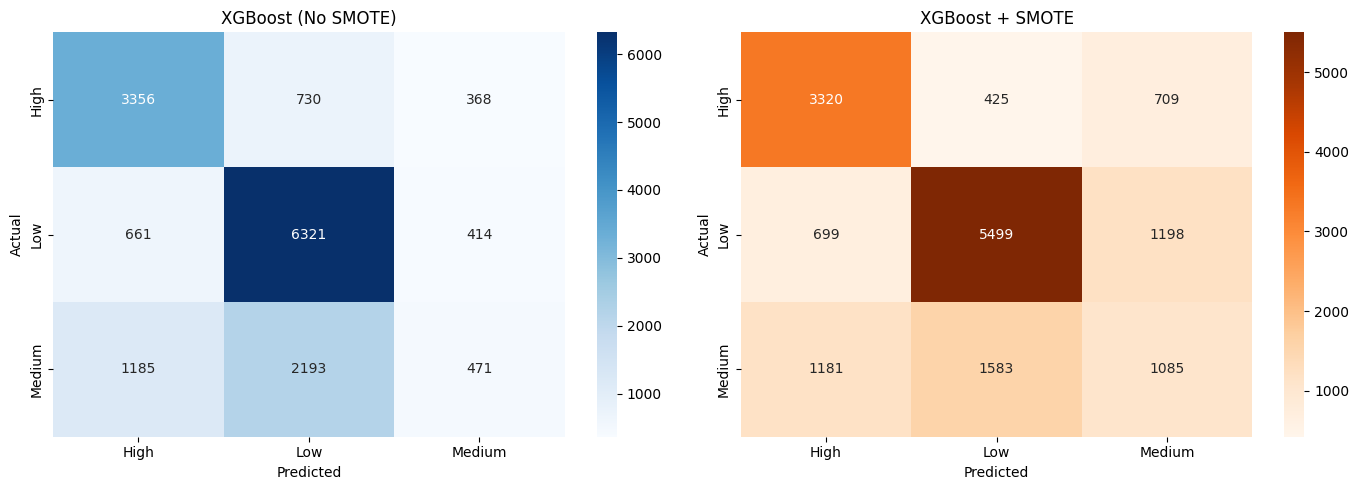

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost without SMOTE
cm1 = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('XGBoost (No SMOTE)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost with SMOTE
cm2 = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('XGBoost + SMOTE')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# HOW TO READ THIS:
# Diagonal = correct predictions (higher is better)
# Off-diagonal = mistakes
# Look at the Medium ROW in both matrices:
#   Without SMOTE: most Medium cases are predicted as Low (the model chickens out)
#   With SMOTE: more Medium cases stay on the diagonal (model is braver)

In [11]:
import shap

# Get the trained XGBoost model out of the SMOTE pipeline
# SHAP needs the raw model, not the full pipeline
xgb_model = smote_pipeline.named_steps['classifier']

# Transform test data through the preprocessor (scaler)
# because the model was trained on scaled data
X_test_processed = smote_pipeline.named_steps['preprocessor'].transform(X_test)

# Take a sample of 2000 rows — SHAP is slow on full dataset
# 2000 is enough to see stable patterns
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_processed), 2000, replace=False)
X_sample = X_test_processed[sample_idx]

# Create SHAP explainer
# TreeExplainer is specifically designed for tree-based models (XGBoost, RF)
# It's exact and fast — no approximation needed
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for our sample
# This asks: "for each prediction, how much did each feature contribute?"
shap_values = explainer.shap_values(X_sample)

# shap_values is a list of 3 arrays (one per class: High, Low, Medium)
# Each array is shape (2000, 5) — 2000 samples × 5 features
print(f"Type: {type(shap_values)}")
print(f"Number of classes: {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")

Type: <class 'numpy.ndarray'>
Number of classes: 2000
Shape per class: (5, 3)


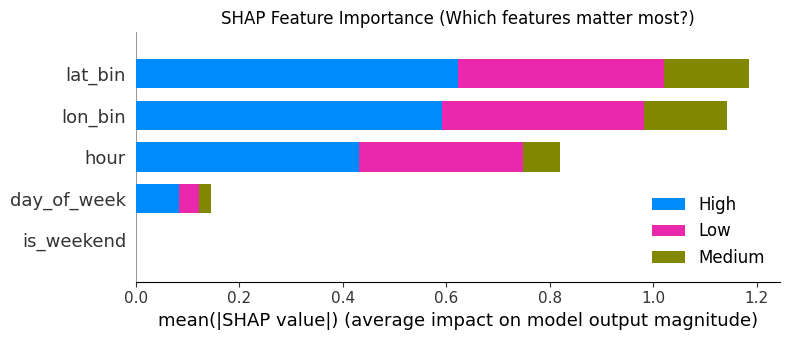

In [12]:
# This shows: across ALL predictions, which features have the
# largest SHAP values (= most influence on the model's decisions)
#
# Think of it as: "What does the model care about most?"

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=features,
    plot_type="bar",        # bar = overall importance
    class_names=le.classes_,
    show=False
)
plt.title("SHAP Feature Importance (Which features matter most?)")
plt.tight_layout()
plt.show()

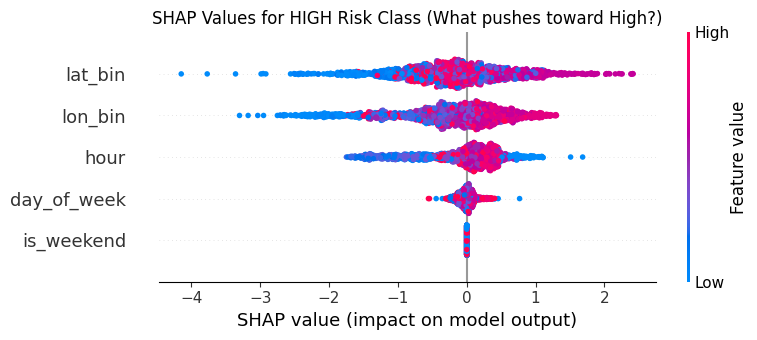

In [15]:
# shap_values shape is (samples, features, classes)
# Class 0 = High, Class 1 = Low, Class 2 = Medium
# So we slice [:, :, 0] to get all samples, all features, for High class

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 0],     # all samples, all features, High class
    X_sample,
    feature_names=features,
    plot_type="dot",
    show=False
)
plt.title("SHAP Values for HIGH Risk Class (What pushes toward High?)")
plt.tight_layout()
plt.show()

In [16]:
import pickle

# Save everything needed for the Streamlit app in one file:
# - the full pipeline (preprocessor + SMOTE + XGBoost)
# - the label encoder (to convert 0,1,2 back to High/Low/Medium)
# - the feature names (so the app knows what columns to create)

model_package = {
    'pipeline': smote_pipeline,
    'label_encoder': le,
    'features': features
}

with open('crime_risk_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print(f"Model saved: crime_risk_model.pkl")
print(f"Features expected: {features}")
print(f"Classes: {list(le.classes_)}")

Model saved: crime_risk_model.pkl
Features expected: ['lat_bin', 'lon_bin', 'hour', 'day_of_week', 'is_weekend']
Classes: ['High', 'Low', 'Medium']


In [18]:
%cd /content
!git clone https://github.com/DivyamAwasthy/chicago-crime-risk-predictor.git
%cd chicago-crime-risk-predictor
!git config user.name "DivyamAwasthy"
!git config user.email "divyamawasthy048@gmail.com"

/content
Cloning into 'chicago-crime-risk-predictor'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 502.18 KiB | 1.74 MiB/s, done.
/content/chicago-crime-risk-predictor


In [19]:
!cp /content/crime_risk_model.pkl .

In [20]:
from google.colab import files
uploaded = files.upload()  # Upload the downloaded 02_modeling.ipynb

KeyboardInterrupt: 